# Séance 7 — CNN : architecture de base

**Objectifs.**
- Comprendre les briques de base d'un CNN (convolution, pooling) en les codant en `nn.Module`.
- Construire un CNN minimal puis une architecture type LeNet, sur MNIST.
- Passer à de vraies photographies (Cats & Dogs) et entraîner un CNN _from scratch_ : mesurer les limites de cet exercice sur un petit jeu de données réaliste.

Vous réutiliserez le `Trainer` de `training_toolbox.py` sans aucune modification : côté outillage, rien de nouveau cette séance, tout se joue dans la définition des modèles.

In [ ]:
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
from PIL import Image

import matplotlib.pyplot as plt

from training_toolbox import Trainer, accuracy

torch.manual_seed(0)

## Partie 1 — Données : MNIST (fourni)

In [ ]:
transform = transforms.ToTensor()  # (C, H, W), valeurs dans [0, 1]

full_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

n_val = 5000
n_train = len(full_train) - n_val
train_set, val_set = random_split(full_train, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256)
test_loader = DataLoader(test_set, batch_size=256)

x_batch, y_batch = next(iter(train_loader))
print("Shape d'un batch d'images :", x_batch.shape)
print("Shape des labels :", y_batch.shape)

## Partie 2 — Un CNN minimal

**Question 2.1.** Codez un CNN avec une seule couche convolutive suivie d'une activation, d'un max pooling, puis d'une couche de classification (calculez vous-même la taille d'entrée de cette dernière couche, à partir des tailles de sortie de la convolution puis du pooling). Affichez le nombre total de paramètres du modèle, entraînez-le avec le `Trainer` pendant 5 epochs, puis évaluez-le sur `test_loader`.

Vous pourrez utiliser les classes suivantes :
* [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
* [`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html#torch.nn.ReLU)
* [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d)
* [`nn.Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html#torch.nn.Flatten)
* [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # TODO

    def forward(self, x):
        # TODO
        pass


# TODO : instancier SimpleCNN, afficher son nombre de paramètres, l'entraîner avec le Trainer
#        pendant 5 epochs et l'évaluer sur test_loader

## Partie 3 — LeNet

**Question 3.1.** Codez l'architecture LeNet représentée ci-dessous : à vous de lire sur le schéma les tailles de filtre des convolutions, les tailles de fenêtre des pooling, ainsi que les tailles des couches denses du classifieur (le nombre d'« Hidden units » de chaque étape). Affichez le nombre de paramètres du modèle, entraînez-le (mêmes hyperparamètres que la partie 2) et évaluez-le sur `test_loader`.

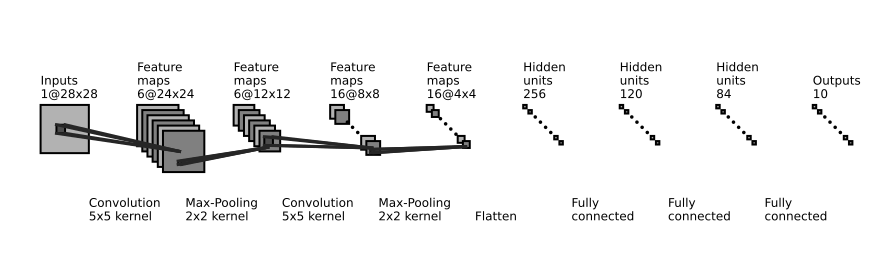

In [ ]:
class LeNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # TODO

    def forward(self, x):
        # TODO
        pass


# TODO : instancier LeNet, afficher son nombre de paramètres (n_params_lenet), l'entraîner avec
#        le Trainer (mêmes hyperparamètres que la partie 2) et l'évaluer sur test_loader

**Question 3.2.** Construisez un MLP `FullyConnectedMNIST` à une seule couche cachée, dont la taille est choisie pour obtenir un nombre total de paramètres proche de celui de LeNet (affichez le nombre de paramètres pour vérifier, inutile de tomber pile dessus). Entraînez-le dans les mêmes conditions, et comparez son accuracy de test à celle de LeNet.

In [ ]:
class FullyConnectedMNIST(nn.Module):
    def __init__(self, hidden_size=55, n_classes=10):
        super().__init__()
        # TODO

    def forward(self, x):
        # TODO
        pass


# TODO : instancier FullyConnectedMNIST avec un hidden_size donnant un nombre de paramètres proche
#        de n_params_lenet, afficher son nombre de paramètres, l'entraîner dans les mêmes conditions
#        et comparer son accuracy de test à celle de LeNet

**Questions.**
- À nombre de paramètres comparable, LeNet fait-il mieux que le MLP sur MNIST ? Est-ce surprenant ?
- Pourquoi une convolution peut-elle représenter des motifs utiles avec beaucoup moins de paramètres qu'une couche `Linear` appliquée à l'image aplatie ?

_Votre réponse ici._

## Partie 4 — Passage à de vraies photos : Cats & Dogs

MNIST est un jeu de données trié, centré, en niveaux de gris et de petite taille : un cas très favorable. Les photographies réelles sont plus grandes, en couleur, mal cadrées, et les jeux de données disponibles sont souvent petits. Le dossier `cats_and_dogs/` contient un tout petit jeu de données (502 images d'entraînement, 500 de test, chats vs chiens) : vous allez y entraîner un CNN _from scratch_ et observer les limites de l'exercice sur un jeu de données aussi réduit.

In [ ]:
class CatsDogsDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = sorted(f for f in os.listdir(root) if f.endswith(".jpg"))
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        fname = self.paths[idx]
        label = 0.0 if fname.startswith("cat") else 1.0
        img = Image.open(os.path.join(self.root, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([label], dtype=torch.float32)


catdog_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

full_train_cd = CatsDogsDataset("cats_and_dogs/train_catdog", transform=catdog_transform)
test_set_cd = CatsDogsDataset("cats_and_dogs/test_catdog", transform=catdog_transform)

n_val_cd = 100
n_train_cd = len(full_train_cd) - n_val_cd
train_set_cd, val_set_cd = random_split(full_train_cd, [n_train_cd, n_val_cd])

train_loader_cd = DataLoader(train_set_cd, batch_size=32, shuffle=True)
val_loader_cd = DataLoader(val_set_cd, batch_size=64)
test_loader_cd = DataLoader(test_set_cd, batch_size=64)

print("Train :", len(train_set_cd), "- Val :", len(val_set_cd), "- Test :", len(test_set_cd))

x_batch_cd, y_batch_cd = next(iter(train_loader_cd))
print("Shape d'un batch d'images :", x_batch_cd.shape)

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, label in zip(axes.ravel(), x_batch_cd, y_batch_cd):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title("chien" if label.item() == 1 else "chat", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def binary_accuracy(preds, y):
    pred_labels = (preds > 0).float()
    return (pred_labels == y).float().mean()

**Question 4.1.** Codez un CNN `CatsDogsCNN` _from scratch_ pour ce problème de classification binaire. Entraînez-le avec le `Trainer` pendant une trentaine d'epochs, tracez les courbes de perte et d'accuracy (train/val), puis évaluez-le sur `test_loader_cd`.

In [ ]:
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO

    def forward(self, x):
        # TODO
        pass


# TODO : instancier CatsDogsCNN, afficher son nombre de paramètres, l'entraîner avec le Trainer
#        pendant une trentaine d'epochs, tracer les courbes de perte et d'accuracy (train/val),
#        puis évaluer sur test_loader_cd

**Questions.**
- Comparez les courbes train/val ici à celles des parties 2 et 3 sur MNIST : le modèle sur-apprend-il davantage ? Pourquoi (taille du jeu de données, complexité des images) ?
- Quels leviers pourraient améliorer ce résultat ?

_Votre réponse ici._

## Bilan

Vous savez maintenant coder et entraîner des CNN simples (`Conv2d`, `MaxPool2d`) avec le `Trainer`, comparer leur efficacité en paramètres à celle d'un MLP, et vous avez observé, sur un vrai petit jeu de données photographique, les limites d'un entraînement from scratch. La séance 8 explore des architectures plus modernes (blocs résiduels, batch normalization) pour aller plus loin.